<a href="https://colab.research.google.com/github/ColinDonahoe119/CBB-Analytics-IGWP/blob/main/in_game_win_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
import os
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from scipy.optimize import minimize

os.chdir("/content/drive/MyDrive/CBB_IGWP")
print(os.getcwd())
sys.path.append(os.getcwd())

from game_eval import game_eval
from ingame_winprob import *
from model_eval import *
from train_model import *
from win_prob_chart import win_prob_chart

/content/drive/MyDrive/CBB_IGWP


Load Source data

In [3]:
possessions = pd.read_csv("possessions.csv")
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print(train.shape)
print(test.shape)
print(possessions.shape)

(435928, 29)
(108722, 29)
(552833, 47)


Train Following Model:

$$z = X_1 \cdot \frac{\text{Lead} \pm \text{poss}}{t^{y_1}} + X_2 \cdot \frac{t}{40} \cdot \frac{\text{adj\_spread}}{t^{y_2}}$$

Each possession calculates the favorite's win probability at time remaining t, given three inputs: current lead, possession, and pregame net rating spread. The possession term represents projected points on the current possession, estimated from each team's offensive and defensive ratings. X1 and X2 are linear coefficients controlling the influence of the lead and spread terms respectively, while Y1 and Y2 are time-decay exponents controlling how quickly each term's impact changes as time remaing decreases.

In [27]:
result = train_model(train)
x1, x2, y1, y2 = result.x
print("Trained coefficients:")
print(f"x1 = {x1:.6f}")
print(f"x2 = {x2:.6f}")
print(f"y1 = {y1:.6f}")
print(f"y2 = {y2:.6f}")
print(f"Log loss: {result.fun:.6f}")

/content/drive/MyDrive/CBB_IGWP/train_model.py:16: RuntimeWarning: overflow encountered in exp
  p = np.clip(1 / (1 + np.exp(-z)), 1e-15, 1 - 1e-15)


Trained coefficients:
x1 = 0.346935
x2 = 2.127803
y1 = 0.277937
y2 = 0.722668
Log loss: 0.372611


In [ ]:
# iterate through test games, evaluate win probabilities for each possession using trained data
test_ids = test['gameId'].unique()
results_test = []
for i, game_id in enumerate(test_ids, 1):
  result = game_eval(test, game_id)
  results_test.append(result)


igwp_test = pd.concat(results_test, ignore_index=True)
igwp_test.to_csv("igwp_test.csv", index=False)
print(f"\nWritten {len(igwp_test):,} rows across {len(test_ids)} games to {"igwp_test.csv"}")


Written 108,722 rows across 788 games to igwp_test.csv


In [4]:
igwp_test = pd.read_csv("igwp_test.csv")
print(igwp_test.shape)

(108722, 26)


In [5]:
# Print the model scores for CBB Analytics current March Madness in game win probability
print("CBB Analytics Bracket scores:")
print(f"Brier Score: {calc_brier(igwp_test, 0):.6f}")
print(f"Log Loss:    {calc_logloss(igwp_test, 0):.6f}")
print(f"Cal MAE:     {calc_cal_mae(igwp_test, 20, 0):.6f}")
print(f"Cal RMSE:    {calc_cal_rmse(igwp_test, 20, 0):.6f}")

CBB Analytics Bracket scores:
Brier Score: 0.119241
Log Loss:    0.371980
Cal MAE:     0.043854
Cal RMSE:    0.053321


In [6]:
# Print scores for trained Logistic Regression Model
print("Logistic Regression scores:")
print(f"Brier Score: {calc_brier(igwp_test, 2):.6f}")
print(f"Log Loss:    {calc_logloss(igwp_test, 2):.6f}")
print(f"Cal MAE:     {calc_cal_mae(igwp_test, 20, 2):.6f}")
print(f"Cal RMSE:    {calc_cal_rmse(igwp_test, 20, 2):.6f}")

Logistic Regression scores:
Brier Score: 0.117291
Log Loss:    0.364188
Cal MAE:     0.011116
Cal RMSE:    0.014380


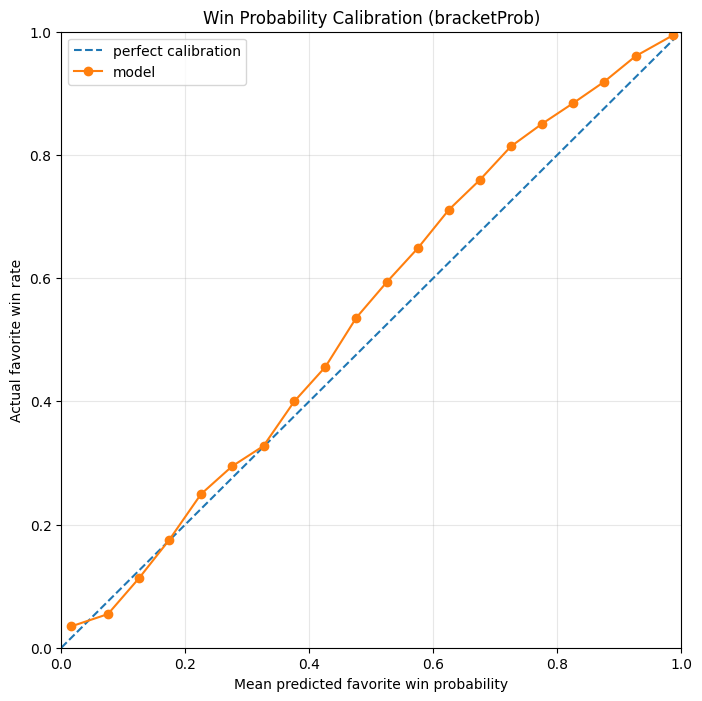

In [7]:
# Bracket Calibration plot
plot_calibration(igwp_test, 20,0)
plt.show()

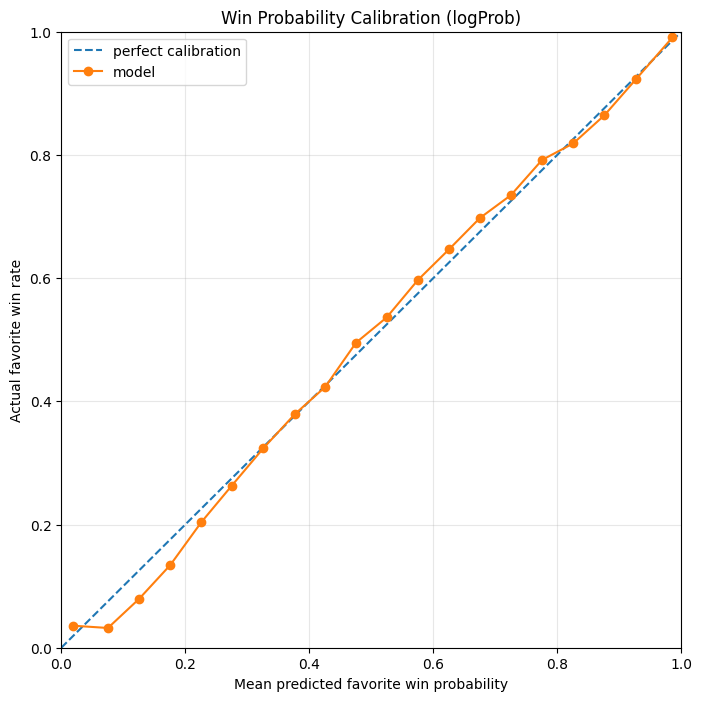

In [8]:
# Logistic Calibration plot
plot_calibration(igwp_test, 20,2)
plt.show()

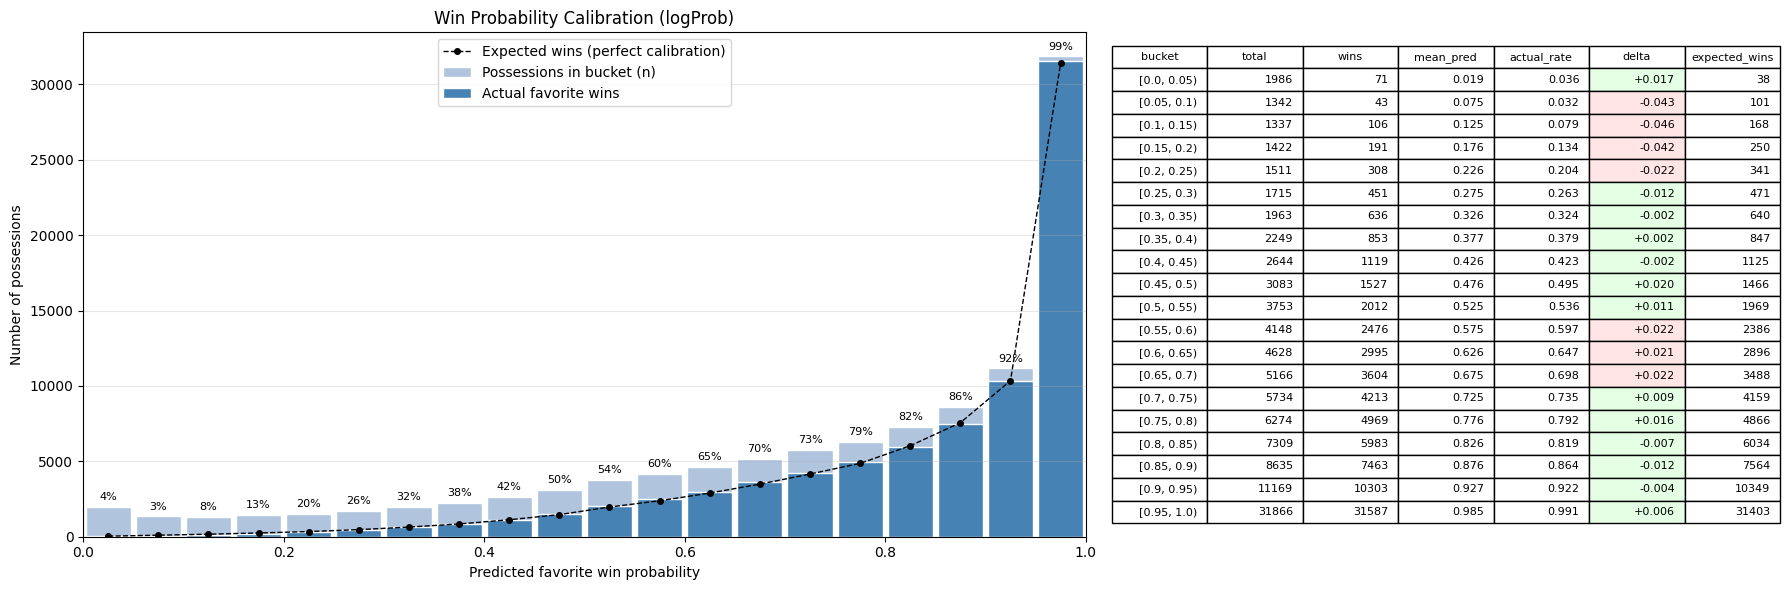

In [9]:
# Calibration historgram bucketed by predicted win probability
plot_winprob_histogram(igwp_test, model=2)
plt.show()

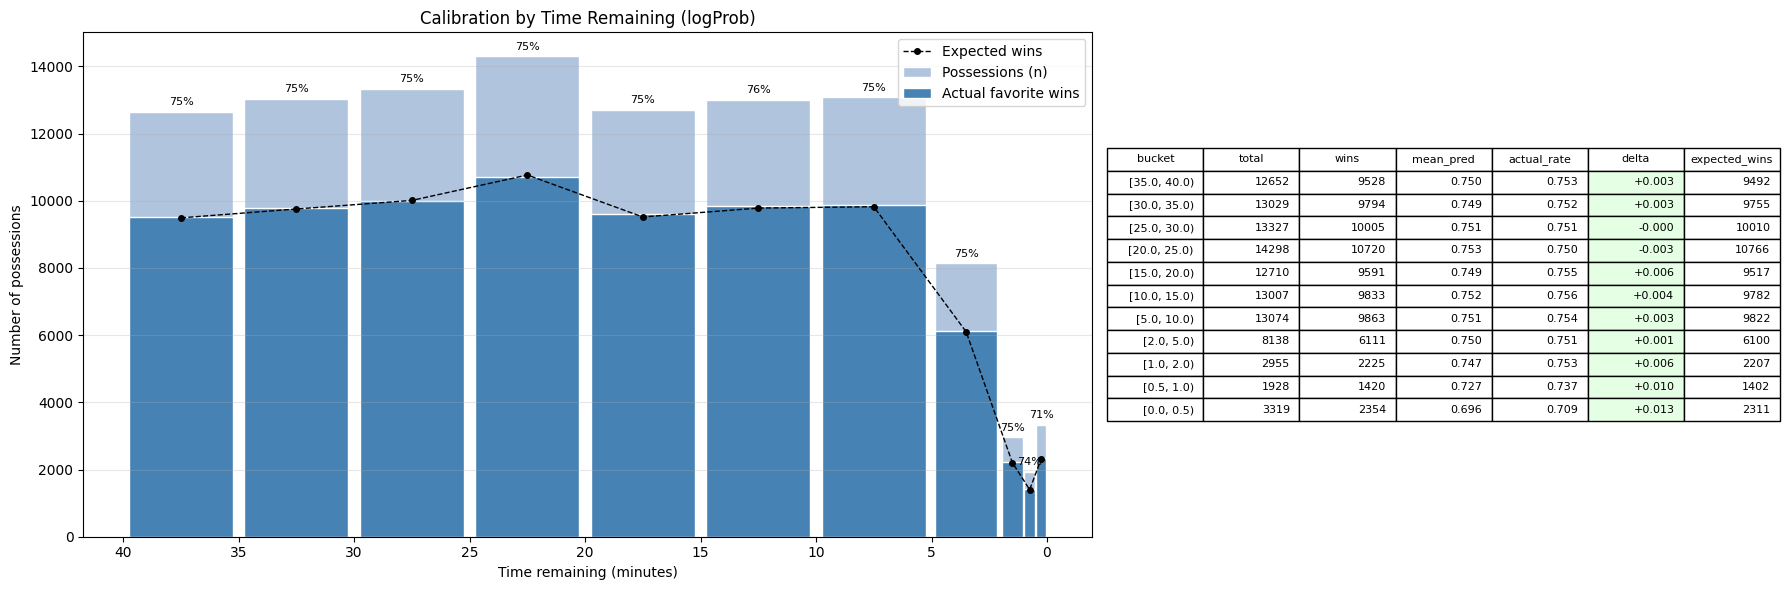

In [10]:
# Calibration historgram bucketed by time remaining
plot_time_histogram(igwp_test, model=2)
plt.show()

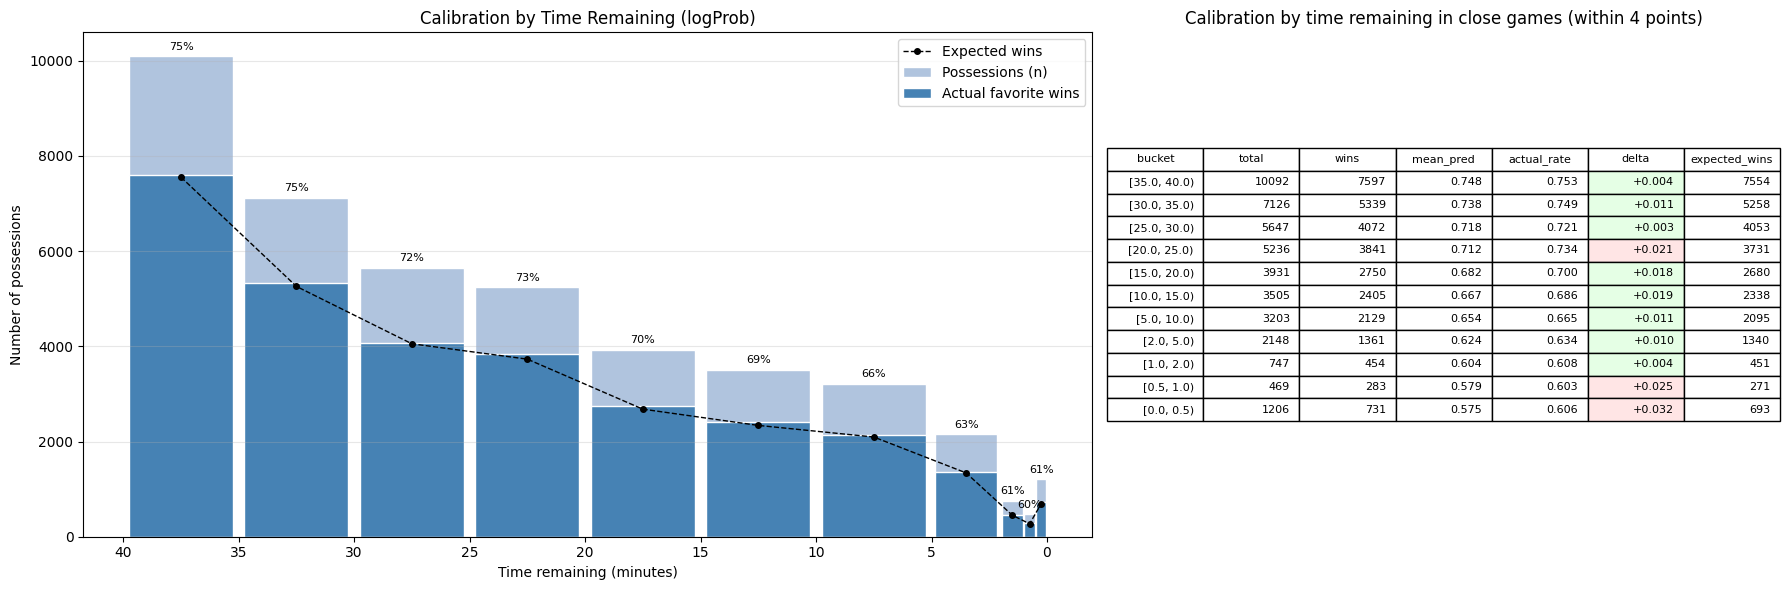

In [11]:
# Evaluates model performance in close game scenarios
filtered_igwp_test = igwp_test[igwp_test['lead'].between(-4, 4)]
plot_time_histogram(filtered_igwp_test, model=2)
plt.title("Calibration by time remaining in close games (within 4 points)")
plt.show()

## **Model Insights**
1. **comebacks**: For each game, finds the possession where the eventual winning team's win probability was at its lowest — i.e., how close they came to losing. Returns one row per game.

2. **swings**: For each game, finds the single possession with the largest change in win probability from the possession before it — the biggest "swing" moment. Returns one row per game.

In [14]:
import pandas as pd
import numpy as np

def comebacks(df: pd.DataFrame) -> pd.DataFrame:
    # Ensure the dataframe is sorted by gameId and possession number for consistent results
    df_sorted = df.sort_values(by=['gameId', 'possNum']).copy()

    # Calculate the probability of the actual winning team for each possession.
    # This is an intermediate step to find the lowest point of the winning team's probability.
    # If 'result' is 1 (favorite won), 'logProb' is the probability of the winning team.
    # If 'result' is 0 (favorite lost), '1 - logProb' is the probability of the winning team (underdog).
    df_sorted['actual_winner_prob_at_possession'] = np.where(
        df_sorted['result'] == 1, df_sorted['logProb'], 1 - df_sorted['logProb']
    )

    # Initialize a list to hold the selected rows (one per game)
    final_rows = []

    # Iterate through each game
    for game_id, game_group in df_sorted.groupby('gameId'):
        # Determine the lowest win probability for the actual winning team across the entire game
        lowest_game_prob = game_group['actual_winner_prob_at_possession'].min()

        # Find the row in the game group where this lowest probability occurred.
        # If multiple possessions have the same lowest probability, take the first one (based on possNum sort).
        comeback_moment_row = game_group[
            game_group['actual_winner_prob_at_possession'] == lowest_game_prob
        ].iloc[0].copy()

        # Add the 'lowest_prob' (as requested in the prompt) to this specific row.
        # This is the lowest probability the actual winning team had during the game.
        comeback_moment_row['lowest_prob'] = lowest_game_prob

        # Append this modified row to our list
        final_rows.append(comeback_moment_row)

    # Concatenate all collected rows into a new DataFrame
    comebacks_df = pd.DataFrame(final_rows)

    # Drop the temporary column used for calculation
    comebacks_df = comebacks_df.drop(columns=['actual_winner_prob_at_possession'])
    comebacks_df = comebacks_df[comebacks_df['lowest_prob'] > 0]

    return comebacks_df

# Example usage:
game_comebacks_df = comebacks(igwp_test)

In [15]:
game_comebacks_df = game_comebacks_df.sort_values(by='lowest_prob', ascending=False)
print(game_comebacks_df[['gameId', 'timeRem', 'favoriteScore','underdogScore','result', 'lowest_prob']].tail(10))

        gameId  timeRem  favoriteScore  underdogScore  result  lowest_prob
41611  2554276     9.53             46             36       0     0.031509
97092  2759615    33.58             19             10       0     0.025124
90360  2753455     9.40             64             52       0     0.019968
86034  2749599     6.57             57             75       1     0.019643
59436  2715930    16.93             50             34       0     0.019633
71198  2736294    17.38             39             28       0     0.018218
5675   2526787     7.77             57             38       0     0.016769
26301  2546868    11.03             49             29       0     0.016584
79404  2742673    14.27             59             41       0     0.015905
25717  2546830    25.02             44             21       0     0.015377


In [24]:
import pandas as pd
import numpy as np

def swings(df: pd.DataFrame) -> pd.DataFrame:
    # Ensure the dataframe is sorted by gameId and possession number for correct consecutive differences
    df_sorted = df.sort_values(by=['gameId', 'possNum']).copy()

    # Calculate the absolute difference in 'logProb' between consecutive possessions within each game
    df_sorted['prob_swing'] = df_sorted.groupby('gameId')['logProb'].diff().abs()

    # Initialize a list to hold the selected rows (one per game)
    final_rows = []

    # Iterate through each game
    for game_id, game_group in df_sorted.groupby('gameId'):
        # Find the maximum 'prob_swing' for the current game
        max_game_swing = game_group['prob_swing'].max()

        # If max_game_swing is NaN (e.g., game has only one possession), skip or handle as appropriate
        if pd.isna(max_game_swing):
            continue

        # Find the row(s) in the game group where this maximum swing occurred.
        # We take the first one if multiple possessions have the same maximum swing.
        swing_moment_row = game_group[
            game_group['prob_swing'] == max_game_swing
        ].iloc[0].copy()

        # Add the 'biggest_swing' to this specific row.
        swing_moment_row['biggest_swing'] = max_game_swing

        # Append this modified row to our list
        final_rows.append(swing_moment_row)

    # Concatenate all collected rows into a new DataFrame
    swings_df = pd.DataFrame(final_rows)

    # Drop the temporary column used for calculation ('prob_swing' is now 'biggest_swing')
    swings_df = swings_df.drop(columns=['prob_swing'])
    swings_df = swings_df[swings_df['biggest_swing'] < 1]

    return swings_df


In [25]:
# Example usage:
game_swings_df = swings(igwp_test)
game_swings_df = game_swings_df.sort_values(by='biggest_swing', ascending=False)
print(game_swings_df[['gameId', 'timeRem', 'favoriteScore','underdogScore','result', 'biggest_swing']].head(10))

         gameId  timeRem  favoriteScore  underdogScore  result  biggest_swing
93326   2755786     0.00             67             68       0       0.846919
105301  2810639     0.00             66             67       0       0.786714
14540   2537763     0.02             79             79       0       0.767825
59740   2715940     0.00             65             67       0       0.752677
90391   2753455     0.03             78             81       0       0.724889
53985   2696331     0.03             81             79       1       0.704639
43998   2555178     0.12             81             79       1       0.696844
75864   2739214     0.01             67             68       0       0.692428
23009   2546430     0.02             67             67       1       0.682472
108309  2829161     0.08             72             73       0       0.675132


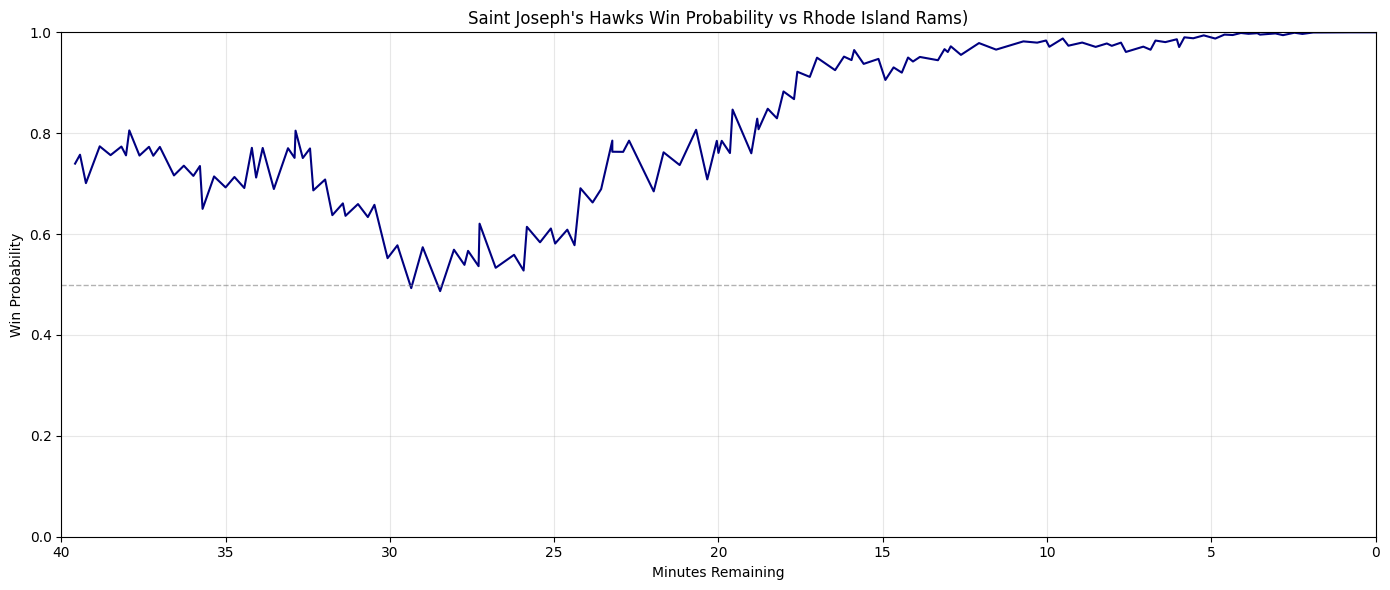

In [32]:
win_prob_chart(igwp_test, 2555841)